In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path("datasets/radar_statistics")

df = pd.read_parquet(
    DATA_DIR/"summary.parquet"
)

df["timestamp"] = pd.to_datetime(
    df.timestamp
)

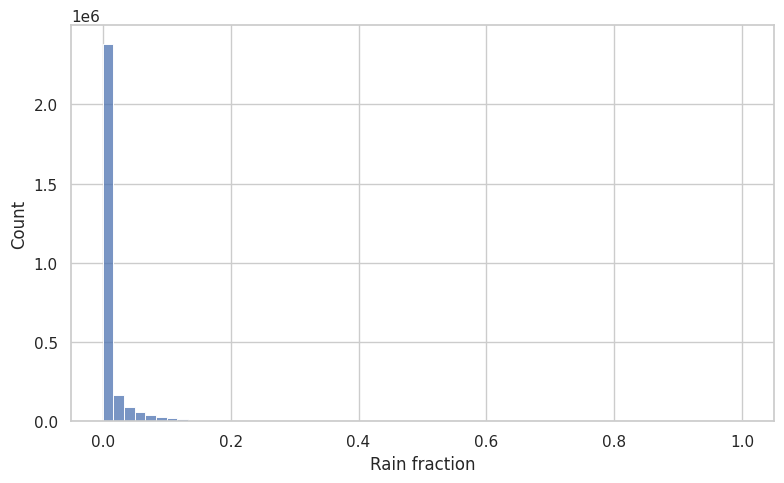

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.rain_fraction,
    bins=60
)

plt.xlabel("Rain fraction")

plt.tight_layout()

plt.savefig(
    "figures/notebook10/rain_fraction_distribution.png",
    dpi=300
)

plt.show()

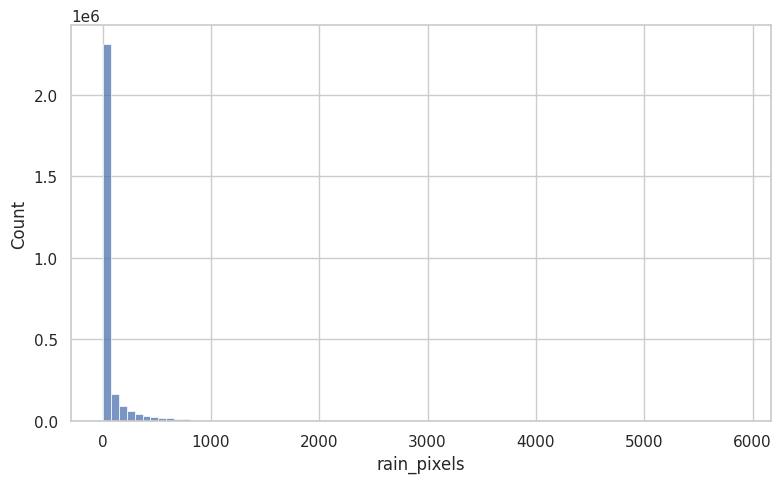

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.rain_pixels,
    bins=80
)

plt.tight_layout()

plt.show()

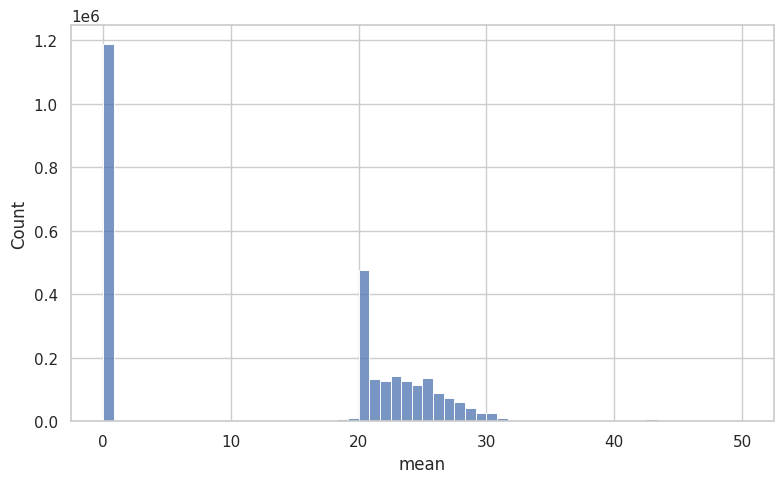

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["mean"],
    bins=60
)

plt.tight_layout()

plt.show()

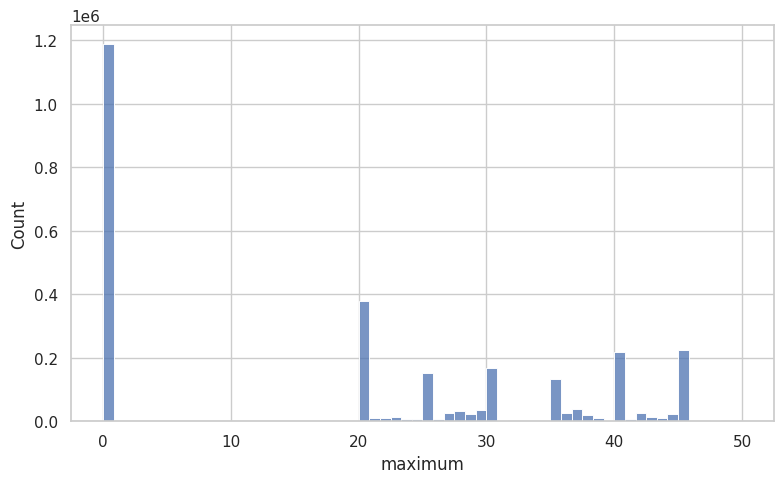

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.maximum,
    bins=60
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_11394/954057972.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_11394/954057972.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
/home/sangonvi/miniconda3/envs/atmoseer/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


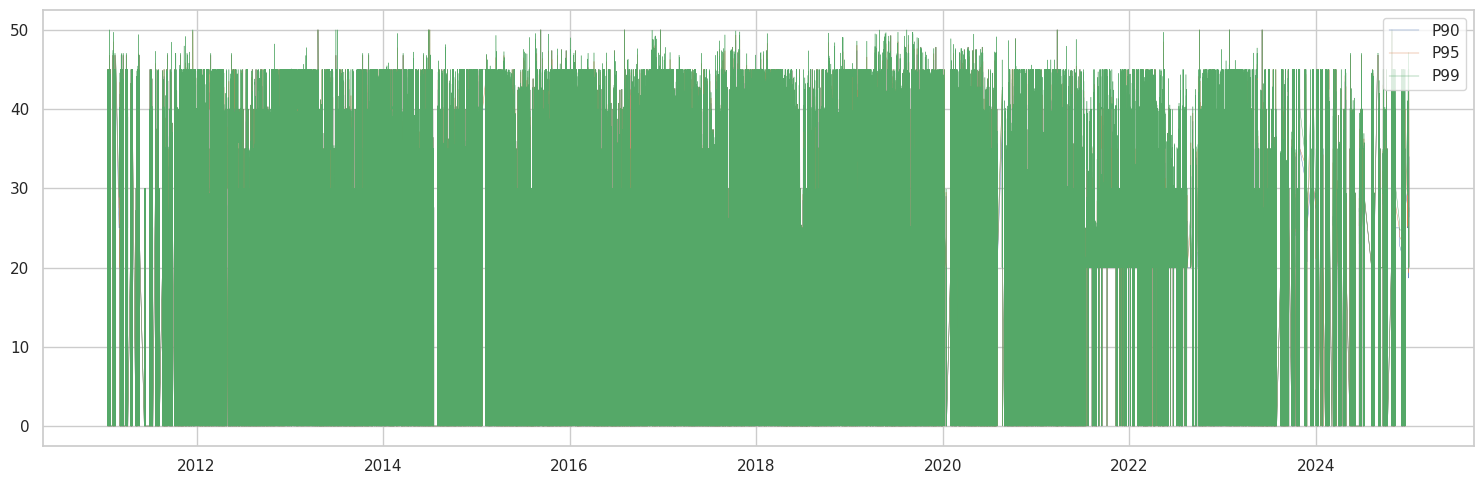

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    df.timestamp,
    df.p90,
    linewidth=0.3,
    label="P90"
)

plt.plot(
    df.timestamp,
    df.p95,
    linewidth=0.3,
    label="P95"
)

plt.plot(
    df.timestamp,
    df.p99,
    linewidth=0.3,
    label="P99"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/notebook10/percentiles.png",
    dpi=300
)

plt.show()

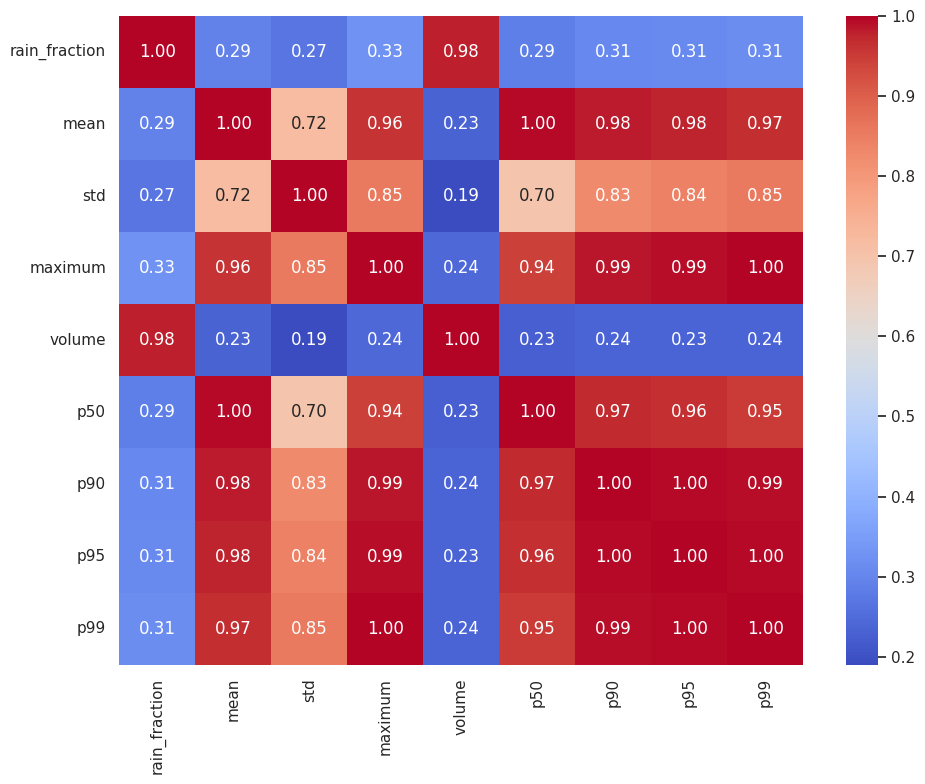

In [10]:
corr = df[
    [
        "rain_fraction",
        "mean",
        "std",
        "maximum",
        "volume",
        "p50",
        "p90",
        "p95",
        "p99"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.tight_layout()

plt.savefig(
    "figures/notebook10/correlation_matrix.png",
    dpi=300
)

plt.show()

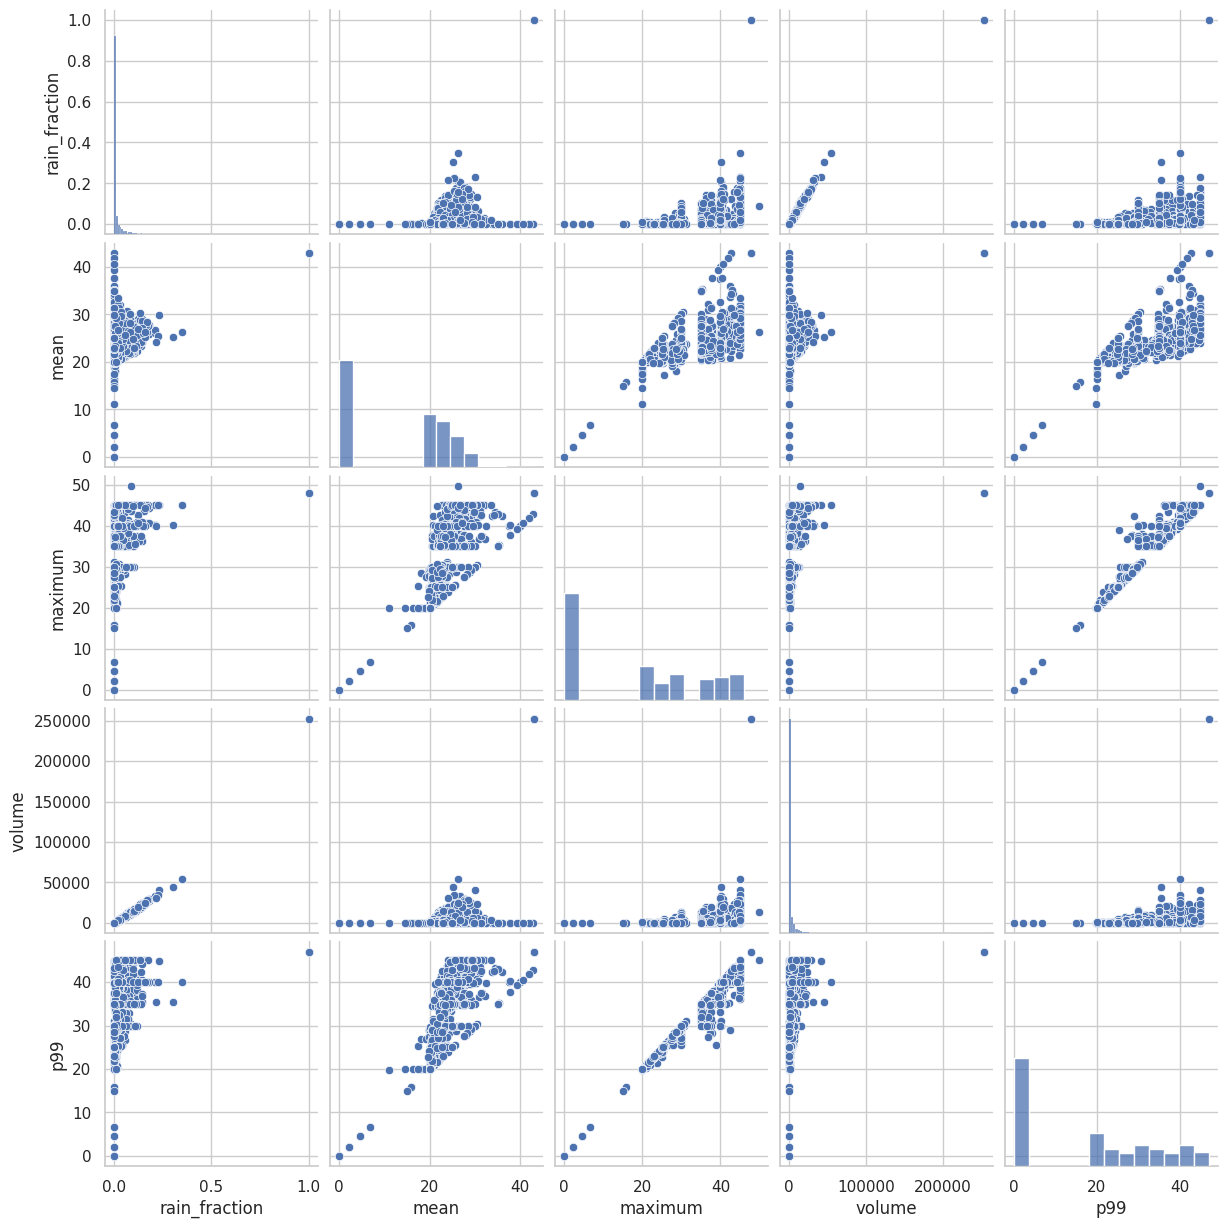

In [11]:
sns.pairplot(
    df.sample(3000),
    vars=[
        "rain_fraction",
        "mean",
        "maximum",
        "volume",
        "p99"
    ]
)

plt.savefig(
    "figures/notebook10/pairplot.png",
    dpi=300
)

In [12]:
dry = (df.rain_fraction == 0).mean()

wet = 1 - dry

print(f"Dry timestamps : {dry:.2%}")
print(f"Wet timestamps : {wet:.2%}")

Dry timestamps : 42.01%
Wet timestamps : 57.99%


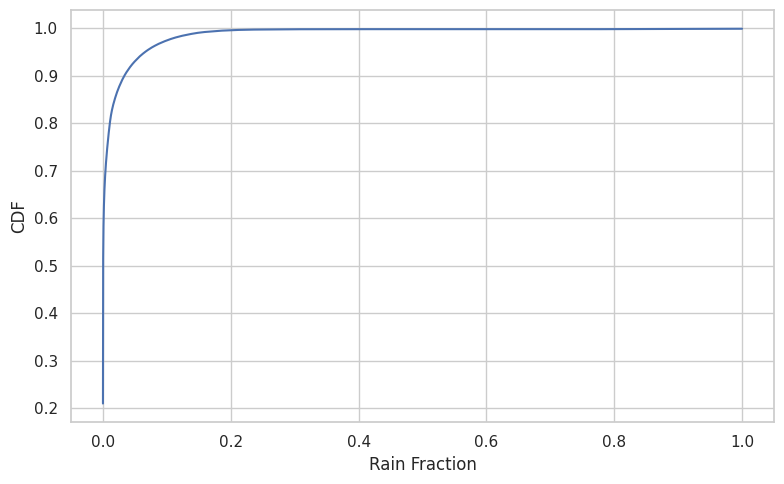

In [13]:
sorted_fraction = df.rain_fraction.sort_values().reset_index(drop=True)

cdf = sorted_fraction.rank(method="average") / len(sorted_fraction)

plt.figure(figsize=(8,5))

plt.plot(
    sorted_fraction,
    cdf
)

plt.xlabel("Rain Fraction")

plt.ylabel("CDF")

plt.tight_layout()

plt.savefig(
    "figures/notebook10/cdf_rain_fraction.png",
    dpi=300
)

plt.show()